In [ ]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from temperature_features import add_temperature_features
from models import get_models
from evaluations import evaluate_model
from evaluations import crossval_predictions
df = pd.read_csv('../data/processed/hea_ml_ready.csv')
df = add_temperature_features(df)

In [6]:
df[["T_e", "logT", "Ce_over_T", "T_tau", "k_ratio"]].head()


,T_e,logT,Ce_over_T,T_tau,k_ratio
0,100,2.000000,0.080158,1611.3,0.003442
1,200,2.301030,0.080135,3720.6,0.046039
2,300,2.477121,0.080102,4903.8,0.126961
3,400,2.602060,0.080066,5431.6,0.198241
4,500,2.698970,0.080028,5591.0,0.258501


In [ ]:
df.to_csv("../data/processed/master_hea_features.csv", index=False)
print("Updated master_hea_features.csv with temperature features")

Updated master_hea_features.csv with temperature features


In [ ]:
df = pd.read_csv("../data/processed/master_hea_features.csv")

target = "C_e"

feature_cols = [
    "T_e", "logT", "T_norm",
    "Ce_over_T", "T_tau", "k_ratio", "Al", "Cr", "Fe", "Co", "Ni", "Mn", "Cu"
]

X = df[feature_cols]
y = df[target]
groups = df["Composition"]

In [10]:
models = get_models(random_state=42)

for name, model in models.items():
    results = evaluate_model(model, X, y, groups)

    print(
        f"{name:8s} | "
        f"R² = {results['r2_mean']:.3f} ± {results['r2_std']:.3f} | "
        f"MAE = {results['mae_mean']:.3f}"
    )


Linear   | R² = 0.924 ± 0.072 | MAE = 60.430
Ridge    | R² = 0.908 ± 0.067 | MAE = 67.269
SVR      | R² = 0.940 ± 0.043 | MAE = 48.804
GBR      | R² = 0.958 ± 0.038 | MAE = 25.871
RF       | R² = 0.961 ± 0.037 | MAE = 23.644


In [11]:
models = get_models(random_state=42)
best_model = models["RF"]   
y_true_all, y_pred_all = crossval_predictions(
    best_model, X, y, groups
)

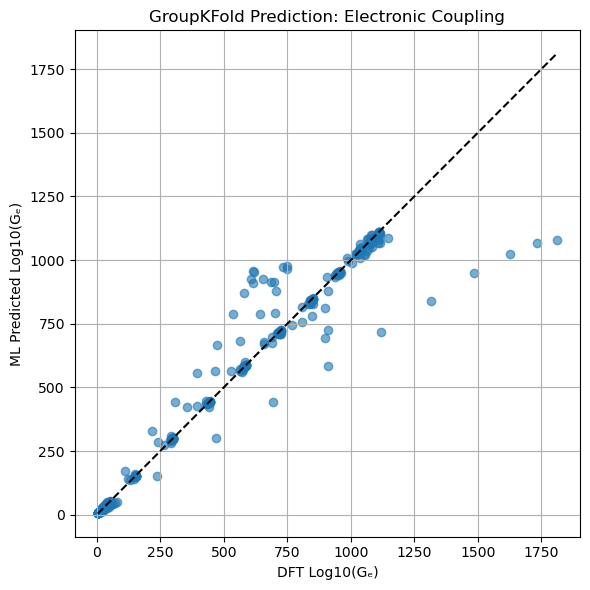

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_true_all, y_pred_all, alpha=0.6)

min_val = min(y_true_all)
max_val = max(y_true_all)

plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.xlabel("DFT Log10(Gₑ)")
plt.ylabel("ML Predicted Log10(Gₑ)")
plt.title("GroupKFold Prediction: Electronic Coupling")

plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Use your best model
best_model = RandomForestRegressor(n_estimators=300, random_state=42)
best_model.fit(X, y)
y_pred = best_model.predict(X)

df_results = pd.DataFrame({
    "y_true": y,
    "y_pred": y_pred,
    "Composition": df["Composition"],
    "T_e": df["T_e"]
})

df_results.to_csv("../data/processed/Log10Ge_predictions.csv", index=False)
print("Saved predictions for sharing/plotting")


Saved predictions for sharing/plotting


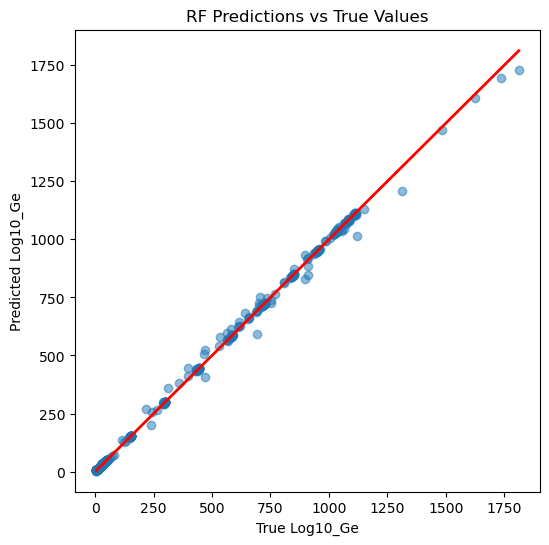

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(df_results["y_true"], df_results["y_pred"], alpha=0.5)
plt.plot([df_results["y_true"].min(), df_results["y_true"].max()],
         [df_results["y_true"].min(), df_results["y_true"].max()],
         color='red', lw=2)
plt.xlabel("True Log10_Ge")
plt.ylabel("Predicted Log10_Ge")
plt.title("RF Predictions vs True Values")
plt.show()


In [19]:
importances = best_model.feature_importances_
features = X.columns
fi_df = pd.DataFrame({"feature": features, "importance": importances})
fi_df.sort_values("importance", ascending=False, inplace=True)
print(fi_df)


      feature    importance
1        logT  3.225795e-01
0         T_e  3.184001e-01
2      T_norm  3.094498e-01
3   Ce_over_T  4.525484e-02
5     k_ratio  1.452115e-03
4       T_tau  1.102421e-03
8          Fe  6.500081e-04
7          Cr  5.868579e-04
10         Ni  4.172618e-04
6          Al  6.615403e-05
9          Co  4.054202e-05
12         Cu  3.383861e-07
11         Mn  2.304813e-08
